In [ ]:
!pip install xgboost shap -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib


In [ ]:
df = pd.read_csv('/content/liver.csv')

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0
})


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [ ]:
df['Albumin_and_Globulin_Ratio'] = (
    df['Albumin_and_Globulin_Ratio']
    .fillna(
        df['Albumin_and_Globulin_Ratio'].median()
    )
)

In [ ]:
X = df.drop('Dataset', axis=1)

y = df['Dataset']

In [ ]:
y = y.replace({
    1:1,
    2:0
})

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.44      0.21      0.28        34
           1       0.73      0.89      0.80        83

    accuracy                           0.69       117
   macro avg       0.59      0.55      0.54       117
weighted avg       0.65      0.69      0.65       117



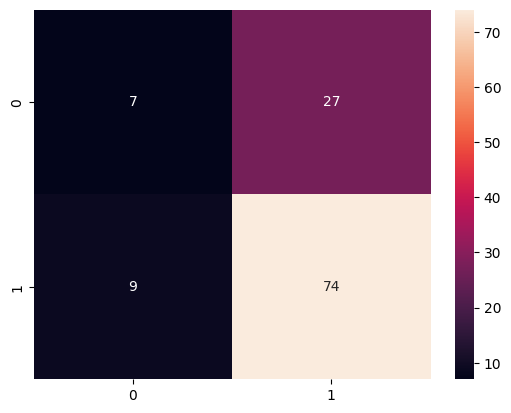

In [ ]:
sns.heatmap(
    confusion_matrix(y_test,pred),
    annot=True,
    fmt='d'
)

plt.show()

In [ ]:
joblib.dump(
    model,
    'liver_model.pkl'
)

joblib.dump(
    scaler,
    'liver_scaler.pkl'
)

['liver_scaler.pkl']

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def run_cv_pipeline(model, X, y, name):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='roc_auc'
    )

    print(f"\n==== {name} ====")
    print("ROC-AUC scores:", scores)
    print("Mean ROC-AUC:", scores.mean())
    print("Std:", scores.std())

In [ ]:
run_cv_pipeline(model, X, y, "liver")


==== liver ====
ROC-AUC scores: [0.73737374 0.72218285 0.70836286 0.76816356 0.7637824 ]
Mean ROC-AUC: 0.7399730830630902
Std: 0.023169125516208634
